<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/09-mnist-noise-robustness/%D0%98%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%83%D1%81%D1%82%D0%BE%D0%B9%D1%87%D0%B8%D0%B2%D0%BE%D1%81%D1%82%D0%B8_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_%D0%BA_%D1%88%D1%83%D0%BC%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Необходимо создать и обучить нейросеть распознавать рукописные цифры.

В качестве набора данных предполагается использовать [MNIST](https://ru.wikipedia.org/wiki/MNIST_(%D0%B1%D0%B0%D0%B7%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85)) копия которого находится в библиотеке [keras](https://keras.io/api/datasets/mnist/)

В процессе практики необходимо загрузить набор данных, преобразовать входной набор в формат, подходящий для обучения нейронной сети (преобразовать картинку в вектор-столбец и выполнить нормализацию данных), подобрать подходящую архитектуру с учетом использования полносвязных слоев, произвести обучение и проверку

Задача: по изображению определить, какая цифра на нем изображена.

In [ ]:
# загрузка датасета MNIST

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

Здесь загружается набор данных MNIST, который уже встроен в библиотеку keras. Данные разделены на две части: обучающую выборку (x_train, y_train) и тестовую (x_test, y_test). Обучающая выборка используется для обучения модели, а тестовая — для проверки качества работы после обучения.

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical


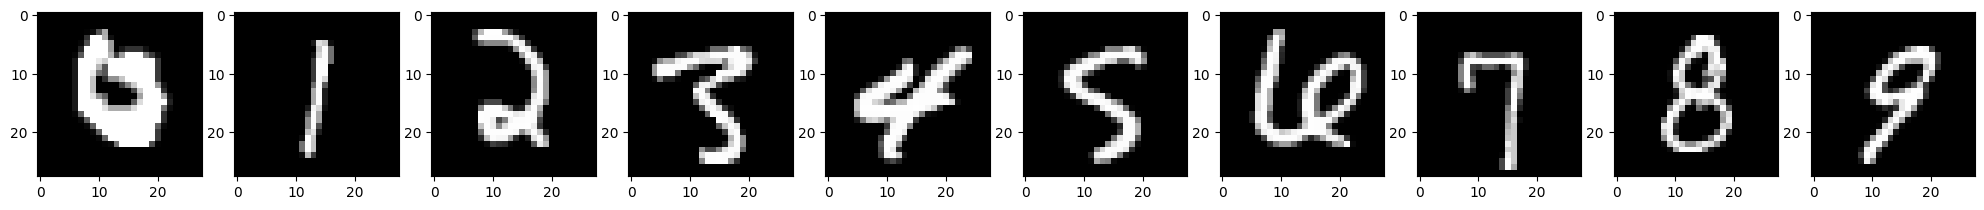

In [ ]:
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
# Подключение класса для работы с изображением
from PIL import Image
# Подключение библиотеки для генерации случайных чисел
import random
# Подключение библиотеки для работы с массивами
import numpy as np

# вывод изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
  label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
  index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
  img = x_train[index] # выбираем из x_train нужное положение
  axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

Перед обучением важно понять, как выглядят данные. На этом шаге выводятся изображения каждой цифры от 0 до 9. Это помогает убедиться, что данные загружены корректно, и визуально оценить качество изображений. Также это даёт представление о задаче, которую предстоит решить нейросети.

Шаг 4. Подготовка данных

Задание: подготовьте данные для нейросети.

Что нужно сделать:
Преобразовать изображения 28×28 → в вектор длины 784
Нормализовать значения пикселей

Подсказка: делите на 255

In [ ]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

x_train = x_train / 255.0
x_test = x_test / 255.0

Шаг 5: создайте полносвязную нейронную сеть.

Требования:

вход: 784
минимум 2 скрытых слоя
выход: 10 классов

Подсказка: используйте relu и softmax

Sequential позволяет выстраивать слои последовательно. Сеть состоит из входного слоя (784 признака), двух скрытых полносвязных слоёв (Dense) и выходного слоя из 10 нейронов — по числу классов.

In [ ]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Шаг 6. Компиляция модели

Задание: настройте процесс обучения.

Подсказка:

оптимизатор: adam
функция потерь: sparse_categorical_crossentropy

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Шаг 7. Обучение модели

Задание: обучите модель.

Подсказка:

epochs: 10
batch_size: 128
validation_split: 0.2

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8918 - loss: 0.3840 - val_accuracy: 0.9482 - val_loss: 0.1813
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9552 - loss: 0.1550 - val_accuracy: 0.9584 - val_loss: 0.1399
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9690 - loss: 0.1061 - val_accuracy: 0.9671 - val_loss: 0.1092
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9750 - loss: 0.0819 - val_accuracy: 0.9702 - val_loss: 0.1012
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9812 - loss: 0.0632 - val_accuracy: 0.9697 - val_loss: 0.1022
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9674 - val_loss: 0.1004
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0408 - val_accuracy: 0.9732 - val_loss: 0.0912
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9896 - loss: 0.0344 - val_accuracy: 0.

Шаг 8. Оценка модели

Задание: проверьте качество модели на тестовой выборке.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Потери на тестовой выборке: {test_loss:.4f}")
print(f"Точность на тестовой выборке: {test_acc:.4f}")
print(f"Точность: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0851
Потери на тестовой выборке: 0.0851
Точность на тестовой выборке: 0.9769
Точность: 97.69%


Шаг 9. Анализ обучения

Задание: постройте графики обучения.

Подсказка: используйте history.history

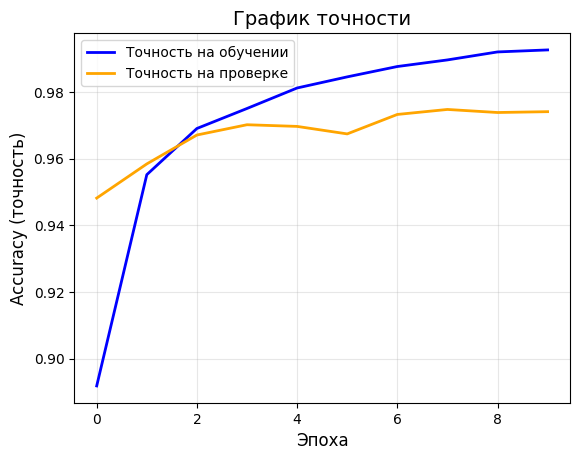

In [ ]:
plt.plot(history.history['accuracy'], label='Точность на обучении', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Точность на проверке', color='orange', linewidth=2)
plt.title('График точности', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy (точность)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

Шаг 10. Предсказание

Задание: проверьте работу модели на примерах.

Подсказка:

используйте model.predict
np.argmax для выбора класса

In [ ]:
x_sample = x_test[:10]
y_true = y_test[:10]
predictions = model.predict(x_sample)
predicted_classes = np.argmax(predictions, axis=1)
for i in range(10):
    print(f"Пример {i+1}: Истинная цифра = {y_true[i]}, Предсказание = {predicted_classes[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Пример 1: Истинная цифра = 7, Предсказание = 7
Пример 2: Истинная цифра = 2, Предсказание = 2
Пример 3: Истинная цифра = 1, Предсказание = 1
Пример 4: Истинная цифра = 0, Предсказание = 0
Пример 5: Истинная цифра = 4, Предсказание = 4
Пример 6: Истинная цифра = 1, Предсказание = 1
Пример 7: Истинная цифра = 4, Предсказание = 4
Пример 8: Истинная цифра = 9, Предсказание = 9
Пример 9: Истинная цифра = 5, Предсказание = 6
Пример 10: Истинная цифра = 9, Предсказание = 9


Вопросы:

Почему изображения нужно преобразовывать в вектор?
Зачем нужна нормализация данных?
Почему на выходном слое используется softmax?
Чем отличается компиляция модели от обучения модели?
Что показывает график функции потерь?

#Вторая часть лабораторной работы. Исследование устойчивости нейронной сети к шуму


Шаг 11. Визуализация тестовых изображений

Задание: отобразите несколько изображений из тестовой выборки.

На этом этапе необходимо ещё раз посмотреть на данные, с которыми работает обученная модель, выведите на экран несколько изображений из тестовой выборки и подпишите их правильными классами.

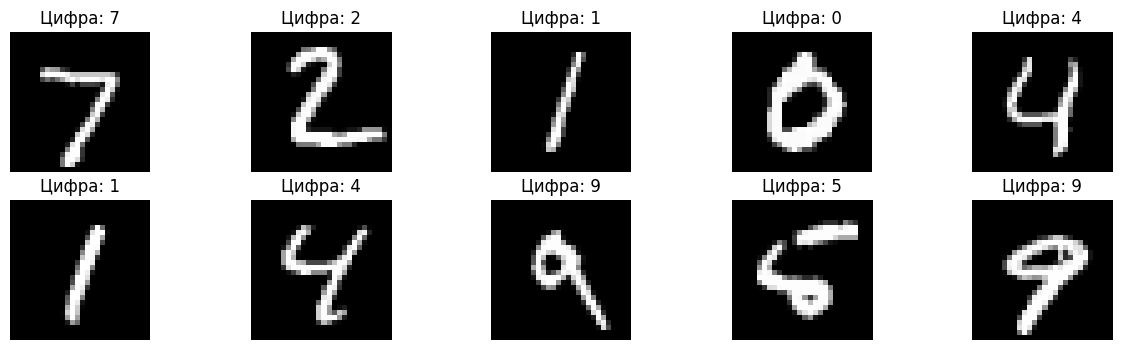

In [ ]:
plt.figure(figsize = (15,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  img = x_test[i].reshape(28,28)
  plt.imshow(img, cmap = 'gray')
  plt.title(f"Цифра: {y_test[i]}", fontsize = 12)
  plt.axis('off')


Шаг 12. Добавление шума к изображениям

Cоздайте искажённую версию тестовой выборки, добавив случайный шум.

На предыдущих этапах модель обучалась на “чистых” изображениях. Однако в реальных условиях данные не всегда бывают идеальными. Изображение может быть размытым, зашумлённым или повреждённым. Поэтому важно проверить, как поведёт себя нейронная сеть, если входные данные немного испортить.

Шум — это случайное изменение значений пикселей. В данной работе предлагается использовать гауссов шум, который добавляется к каждому пикселю независимо. После добавления шума значения пикселей могут выйти за допустимые пределы, поэтому результат необходимо ограничить диапазоном от 0 до 1.

Что нужно сделать: создайте новую выборку X_test_noisy, содержащую зашумлённые изображения.

In [ ]:
noise = np.random.normal(0, 0.3, x_test.shape)
X_test_noisy = x_test + noise
X_test_noisy = np.clip(X_test_noisy, 0, 1)

Шаг 13. Сравнение исходных и искажённых изображений

Визуально сравните изображения до и после добавления шума.

После создания искажённой выборки необходимо посмотреть, как именно изменились изображения, выведите рядом оригинальное изображение и его зашумлённую версию.

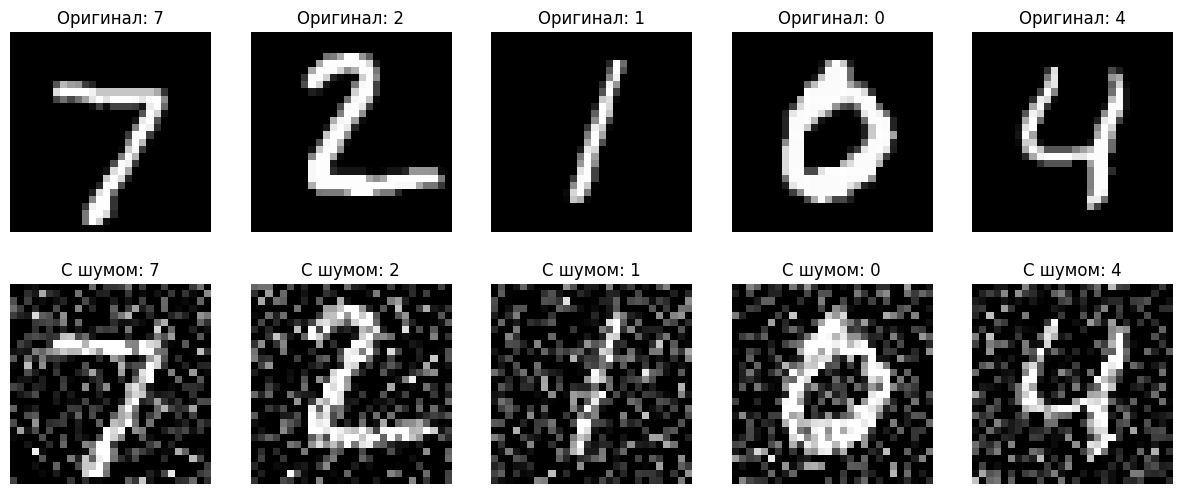

In [ ]:
plt.figure(figsize = (15, 6))
for i in range(5):
  plt.subplot(2,5,i+1)
  img_clean = x_test[i].reshape(28,28)
  plt.imshow(img_clean, cmap = 'gray')
  plt.title(f"Оригинал: {y_test[i]}")
  plt.axis('off')

  plt.subplot(2,5, i+6)
  img_noisy = X_test_noisy[i].reshape(28,28)
  plt.imshow(img_noisy, cmap = 'gray')
  plt.title(f"С шумом: {y_test[i]}")
  plt.axis('off')
plt.show()

Шаг 14. Оценка модели на искажённых данных

Проверьте, как изменится качество работы модели на зашумлённой тестовой выборке.

После визуального анализа необходимо перейти к численной оценке. Ранее модель уже показала высокую точность на обычных тестовых данных. Теперь важно сравнить это значение с точностью на искажённых изображениях. Такой эксперимент позволяет на практике показать, что высокая точность на “удобных” данных ещё не означает устойчивость модели.

Что нужно сделать: вычислите значение функции потерь и точность модели на X_test_noisy.

In [ ]:
loss_noisy, accuracy_noisy = model.evaluate(X_test_noisy, y_test)
print(f"Потери на зашумленной тестовой выборке: {loss_noisy:.4f}")
print(f"Точность на зашумленной тестовой выборке: {accuracy_noisy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6758 - loss: 1.8516
Потери на зашумленной тестовой выборке: 1.8516
Точность на зашумленной тестовой выборке: 0.6758


Шаг 15. Построение сравнительной диаграммы точности

Визуализируйте точность модели на чистых и зашумлённых данных.

Что нужно сделать: постройте график, на котором будут показаны две величины — точность на исходных данных и точность на искажённых данных.

Подсказка: используйте plt.bar. По оси X можно подписать категории как «Чистые данные» и «Зашумлённые данные».

Text(0.5, 1.0, 'Сравнение точности модели на чистых и зашумлённых данных')

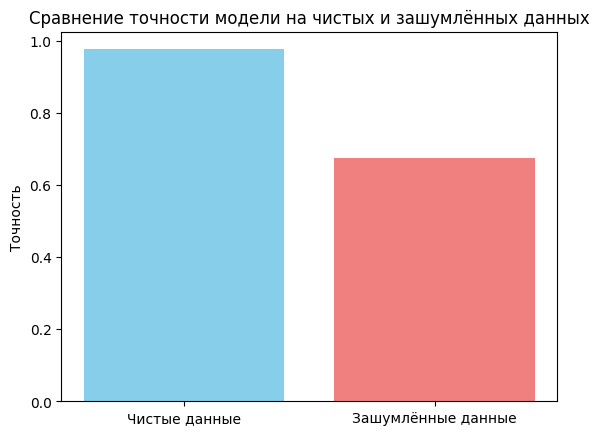

In [ ]:
labels = ['Чистые данные', 'Зашумлённые данные']
accuracies = [accuracy, accuracy_noisy]

plt.bar(labels, accuracies, color=['skyblue', 'lightcoral'])
plt.ylabel('Точность')
plt.title('Сравнение точности модели на чистых и зашумлённых данных')

Шаг 16. Получение предсказаний модели

Задание: получите предсказанные классы для зашумлённых изображений.

Чтобы перейти к анализу конкретных ошибок, необходимо сначала вычислить предсказания модели. На выходе сеть возвращает вероятности принадлежности к каждому из 10 классов. Для выбора окончательного ответа используется индекс максимального значения.

Что нужно сделать: выполните предсказание на зашумлённой выборке и определите итоговый класс для каждого изображения.

In [ ]:
predictions_noisy = model.predict(X_test_noisy)
predicted_classes_noisy = np.argmax(predictions_noisy, axis=1)
print(f"{predicted_classes_noisy[:10]}")
print(f"{y_test[:10]}")
print(f"{predicted_classes_noisy[-10:]}")
print(f"{y_test[-10:]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[3 2 2 0 4 2 8 3 6 8]
[7 2 1 0 4 1 4 9 5 9]
[3 8 9 0 8 2 3 4 5 6]
[7 8 9 0 1 2 3 4 5 6]


Шаг 17. Визуализация ошибок модели

Задание: отобразите изображения, на которых модель ошиблась.

Этот шаг позволяет увидеть, какие именно изображения вызывают затруднения у модели. Часто ошибки возникают на цифрах, которые после добавления шума становятся похожими на другие классы.

Что нужно сделать: найдите индексы ошибочных предсказаний и выведите несколько таких изображений с указанием предсказанного и истинного класса.

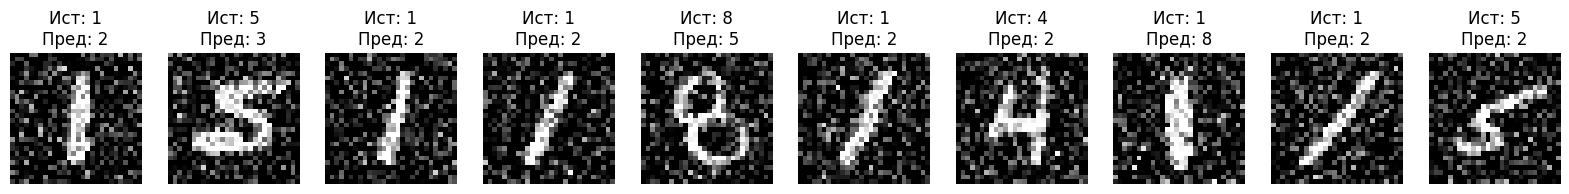

In [ ]:
incorrect_indices = np.where(predicted_classes_noisy != y_test)[0]

num_errors_to_display = 10
if len(incorrect_indices) > num_errors_to_display:
    display_indices = np.random.choice(incorrect_indices, num_errors_to_display, replace=False)
else:
    display_indices = incorrect_indices

plt.figure(figsize=(20, 4))
for i, index in enumerate(display_indices):
    image = (X_test_noisy[index] * 255).reshape(28, 28).astype(np.uint8)
    true_label = y_test[index]
    predicted_label = predicted_classes_noisy[index]

    plt.subplot(1, num_errors_to_display, i + 1)
    plt.imshow(Image.fromarray(image), cmap='gray')
    plt.title(f"Ист: {true_label}\nПред: {predicted_label}")
    plt.axis('off')

Вопросы

Почему точность модели уменьшается после добавления шума? Искажает важные признаки цифр

Какие цифры чаще всего распознаются неправильно и почему? 3 8 9

Как можно повысить устойчивость модели к шуму? Обучать модель на уже зашум данных

In [ ]:
import tensorflow as tf

def add_gaussian_noise(image, std_dev=0.3):
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=std_dev, dtype=tf.float32)
    noisy_image = image + noise
    return tf.clip_by_value(noisy_image, 0.0, 1.0)

x_train_noisy_augmented = add_gaussian_noise(tf.constant(x_train, dtype=tf.float32), std_dev=0.3).numpy()

model_noisy_robust = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_noisy_robust.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

print("Обучение новой модели на зашумленных данных для повышения устойчивости...")
history_robust = model_noisy_robust.fit(x_train_noisy_augmented, y_train,
                                        epochs=10,
                                        batch_size=128,
                                        validation_split=0.2)

loss_robust, accuracy_robust = model_noisy_robust.evaluate(X_test_noisy, y_test)
print(f"\nПотери новой модели на зашумленной тестовой выборке: {loss_robust:.4f}")
print(f"Точность новой модели на зашумленной тестовой выборке: {accuracy_robust:.4f}")

Обучение новой модели на зашумленных данных для повышения устойчивости...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8384 - loss: 0.5399 - val_accuracy: 0.9062 - val_loss: 0.3144
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9187 - loss: 0.2724 - val_accuracy: 0.9293 - val_loss: 0.2455
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9406 - loss: 0.1968 - val_accuracy: 0.9359 - val_loss: 0.2165
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9559 - loss: 0.1472 - val_accuracy: 0.9435 - val_loss: 0.1953
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9663 - loss: 0.1140 - val_accuracy: 0.9408 - val_loss: 0.2004
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9757 - loss: 0.0846 - val_accuracy: 0.9447 - val_loss: 0.1890
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9828 - loss: 0.0627 - val_accuracy: 0.9438 - val_loss: 0.1957
Epoch 8/10
375/375 ━━━━━━━━━━